In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("TrainDDOS_RF") \
    .config("spark.hadoop.fs.defaultFS", "hdfs://localhost:9000") \
    .getOrCreate()
spark

In [33]:
paths = [
    "hdfs://localhost:9000/data/01-12/DrDoS_NetBIOS.csv",
    "hdfs://localhost:9000/data/01-12/DrDoS_NTP.csv",
    "hdfs://localhost:9000/data/01-12/UDPLag.csv",
    "hdfs://localhost:9000/data/01-12/Syn.csv",
    "hdfs://localhost:9000/data/01-12/DrDoS_MSSQL.csv",
    "hdfs://localhost:9000/data/01-12/DrDoS_SNMP.csv",
    "hdfs://localhost:9000/data/01-12/DrDoS_DNS.csv",
    "hdfs://localhost:9000/data/01-12/DrDoS_LDAP.csv",
]

df_raw = spark.read.option("header", True).option("inferSchema", True).csv(paths)

In [34]:
output_path = "file:///E:/BIGDATA/data/parquet/cic_ddos_2019_10gb.parquet"
df_raw.write.mode("overwrite").parquet(output_path)


In [ ]:
spark.stop()

In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("statistic_ddos")
    .config("spark.hadoop.fs.defaultFS", "file:///")   
    .getOrCreate()
)

spark


In [40]:
parquet_path = r"E:\BIGDATA\data\parquet\cic_ddos_2019_10gb.parquet"

df_raw = spark.read.parquet(parquet_path)
df_raw.printSchema()

root
 |-- Unnamed: 0: integer (nullable = true)
 |-- Flow ID: string (nullable = true)
 |--  Source IP: string (nullable = true)
 |--  Source Port: integer (nullable = true)
 |--  Destination IP: string (nullable = true)
 |--  Destination Port: integer (nullable = true)
 |--  Protocol: integer (nullable = true)
 |--  Timestamp: timestamp (nullable = true)
 |--  Flow Duration: integer (nullable = true)
 |--  Total Fwd Packets: integer (nullable = true)
 |--  Total Backward Packets: integer (nullable = true)
 |-- Total Length of Fwd Packets: double (nullable = true)
 |--  Total Length of Bwd Packets: double (nullable = true)
 |--  Fwd Packet Length Max: double (nullable = true)
 |--  Fwd Packet Length Min: double (nullable = true)
 |--  Fwd Packet Length Mean: double (nullable = true)
 |--  Fwd Packet Length Std: double (nullable = true)
 |-- Bwd Packet Length Max: double (nullable = true)
 |--  Bwd Packet Length Min: double (nullable = true)
 |--  Bwd Packet Length Mean: double (nullabl

In [ ]:
from pyspark.sql import functions as F
import re

def norm(c):
    c = c.strip()
    c = re.sub(r"\s+", " ", c).replace("/", " per ")
    c = re.sub(r"[^0-9a-zA-Z ]+", " ", c)
    c = re.sub(r"\s+", "_", c).lower()
    return c.strip("_")

df = df_raw
for c in df_raw.columns:
    df = df.withColumnRenamed(c, norm(c))


print("Rows:", df.count())
df.printSchema()
df.show(5, truncate=False)

Rows: 24207109
root
 |-- unnamed_0: integer (nullable = true)
 |-- flow_id: string (nullable = true)
 |-- source_ip: string (nullable = true)
 |-- source_port: integer (nullable = true)
 |-- destination_ip: string (nullable = true)
 |-- destination_port: integer (nullable = true)
 |-- protocol: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- flow_duration: integer (nullable = true)
 |-- total_fwd_packets: integer (nullable = true)
 |-- total_backward_packets: integer (nullable = true)
 |-- total_length_of_fwd_packets: double (nullable = true)
 |-- total_length_of_bwd_packets: double (nullable = true)
 |-- fwd_packet_length_max: double (nullable = true)
 |-- fwd_packet_length_min: double (nullable = true)
 |-- fwd_packet_length_mean: double (nullable = true)
 |-- fwd_packet_length_std: double (nullable = true)
 |-- bwd_packet_length_max: double (nullable = true)
 |-- bwd_packet_length_min: double (nullable = true)
 |-- bwd_packet_length_mean: double (nullable 

In [42]:
from pyspark.sql import functions as F

label_col = "label" if "label" in df.columns else "label_int"

label_stats = (
    df.groupBy(label_col)
      .count()
      .orderBy(F.desc("count"))
)

label_stats.show(50, truncate=False)

pdf_label = label_stats.toPandas()


+-------------+-------+
|label        |count  |
+-------------+-------+
|DrDoS_SNMP   |5159870|
|DrDoS_DNS    |5071011|
|DrDoS_MSSQL  |4522492|
|DrDoS_NetBIOS|4093279|
|DrDoS_LDAP   |2179930|
|Syn          |1582289|
|DrDoS_NTP    |1202642|
|UDP-lag      |366461 |
|BENIGN       |28696  |
|WebDDoS      |439    |
+-------------+-------+



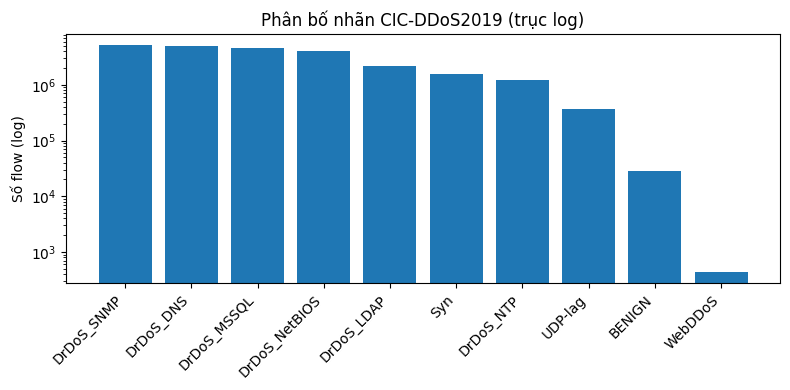

In [43]:
import matplotlib.pyplot as plt

pdf_label_sorted = pdf_label.sort_values("count", ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(pdf_label_sorted[label_col].astype(str), pdf_label_sorted["count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Số flow (log)")
plt.title("Phân bố nhãn CIC-DDoS2019 (trục log)")
plt.yscale("log")
plt.tight_layout()
plt.show()


In [44]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

# Đổi tất cả nhãn != benign thành attack
df2 = df.withColumn(
    "label2",
    F.when(F.lower(F.col("label")) == "benign", F.lit("benign")).otherwise(F.lit("attack"))
)

# Ép cột thời gian, nếu cần
df2 = df2.withColumn("ts", F.to_timestamp("timestamp"))

# Gom theo phút và nhãn đơn giản benign/attack
df_min = (
    df2
    .withColumn("minute", F.date_trunc("minute", F.col("ts")))
    .groupBy("minute", "label2")
    .count()
)

pdf_min = df_min.toPandas().sort_values("minute")

# Pivot: mỗi phút có 2 cột: benign, attack
pdf_pivot = (
    pdf_min
    .pivot(index="minute", columns="label2", values="count")
    .fillna(0)
    .reset_index()
)

# Tính tổng và tỉ lệ benign
pdf_pivot["total"] = pdf_pivot["benign"] + pdf_pivot["attack"]
pdf_pivot["benign_ratio"] = pdf_pivot["benign"] / pdf_pivot["total"].replace(0, 1)


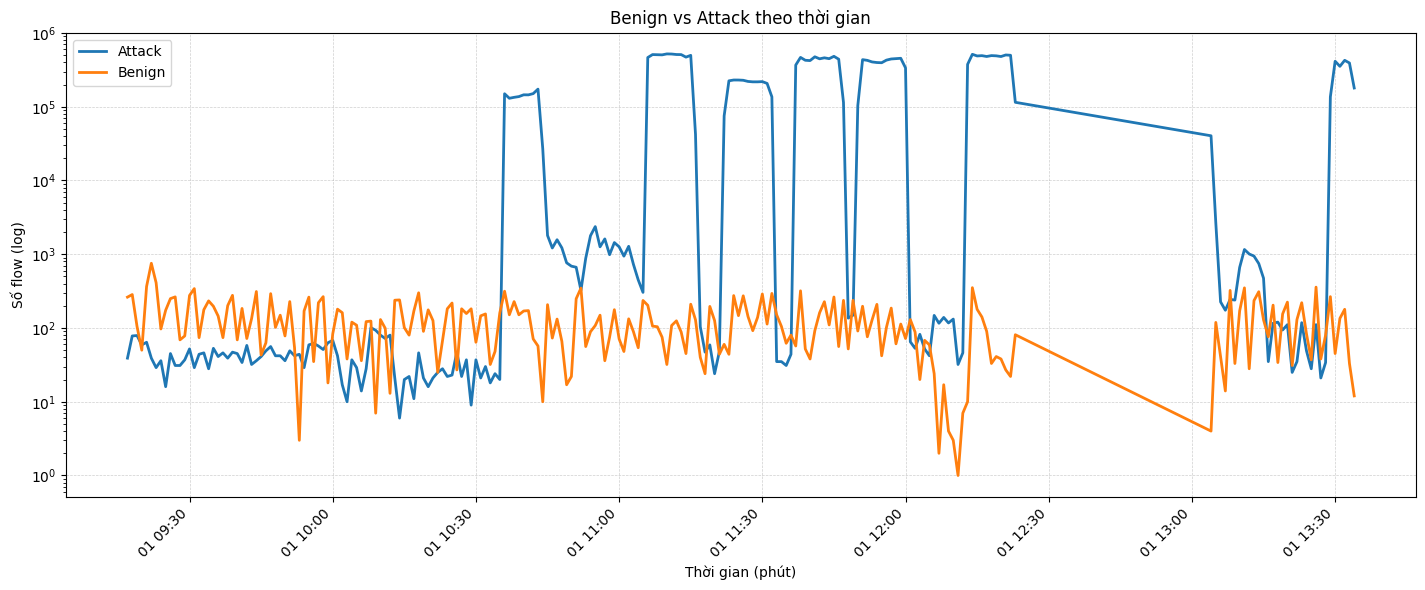

In [53]:
plt.figure(figsize=(28, 6))

plt.subplot(1, 2, 1)

plt.plot(
    pdf_pivot["minute"],
    pdf_pivot["attack"],
    label="Attack",
    linewidth=2.0,
)

plt.plot(
    pdf_pivot["minute"],
    pdf_pivot["benign"],
    label="Benign",
    linewidth=2.0,
)

plt.yscale("log")
plt.xlabel("Thời gian (phút)")
plt.ylabel("Số flow (log)")
plt.title("Benign vs Attack theo thời gian")

plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


In [54]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

# Chuẩn hóa nhãn: giữ nguyên tên tấn công, benign giữ nguyên
df_time = df.withColumn(
    "label_clean",
    F.when(F.lower(F.col("label")) == "benign", F.lit("BENIGN")).otherwise(F.col("label"))
)

df_time = df_time.withColumn("ts", F.to_timestamp("timestamp"))

df_min_label = (
    df_time
    .withColumn("minute", F.date_trunc("minute", F.col("ts")))
    .groupBy("minute", "label_clean")
    .count()
)

pdf_min_label = df_min_label.toPandas().sort_values("minute")

pivot_counts = (
    pdf_min_label
    .pivot(index="minute", columns="label_clean", values="count")
    .fillna(0)
    .reset_index()
)

cols_plot = [c for c in pivot_counts.columns if c != "minute"]


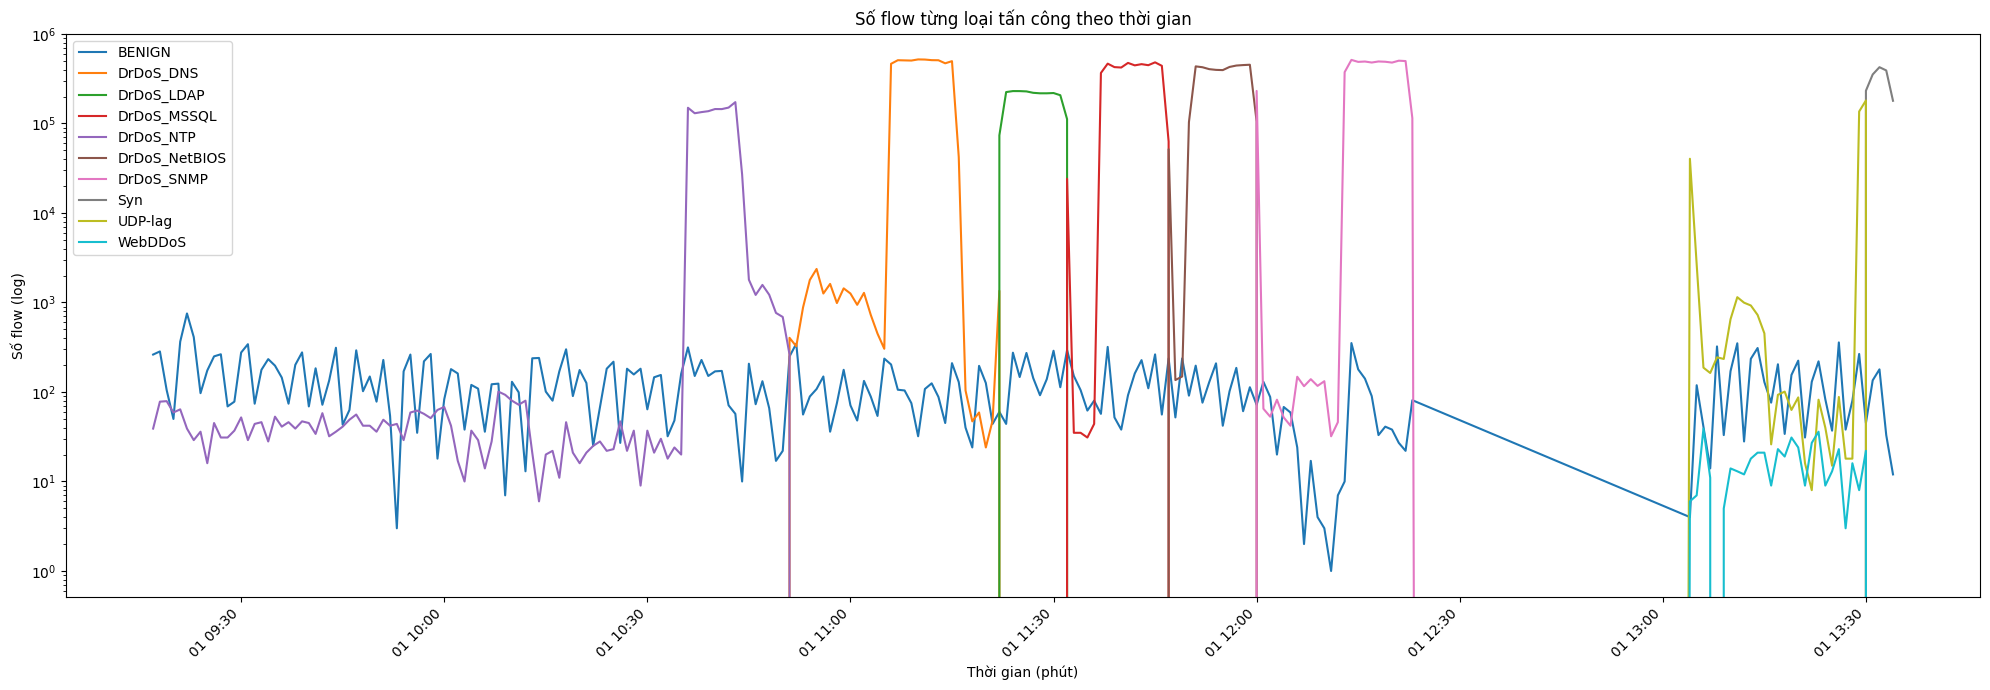

In [61]:
plt.figure(figsize=(20, 7))

for col in cols_plot:
    plt.plot(pivot_counts["minute"], pivot_counts[col], label=str(col))

plt.yscale("log")
plt.xlabel("Thời gian (phút)")
plt.ylabel("Số flow (log)")
plt.title("Số flow từng loại tấn công theo thời gian")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


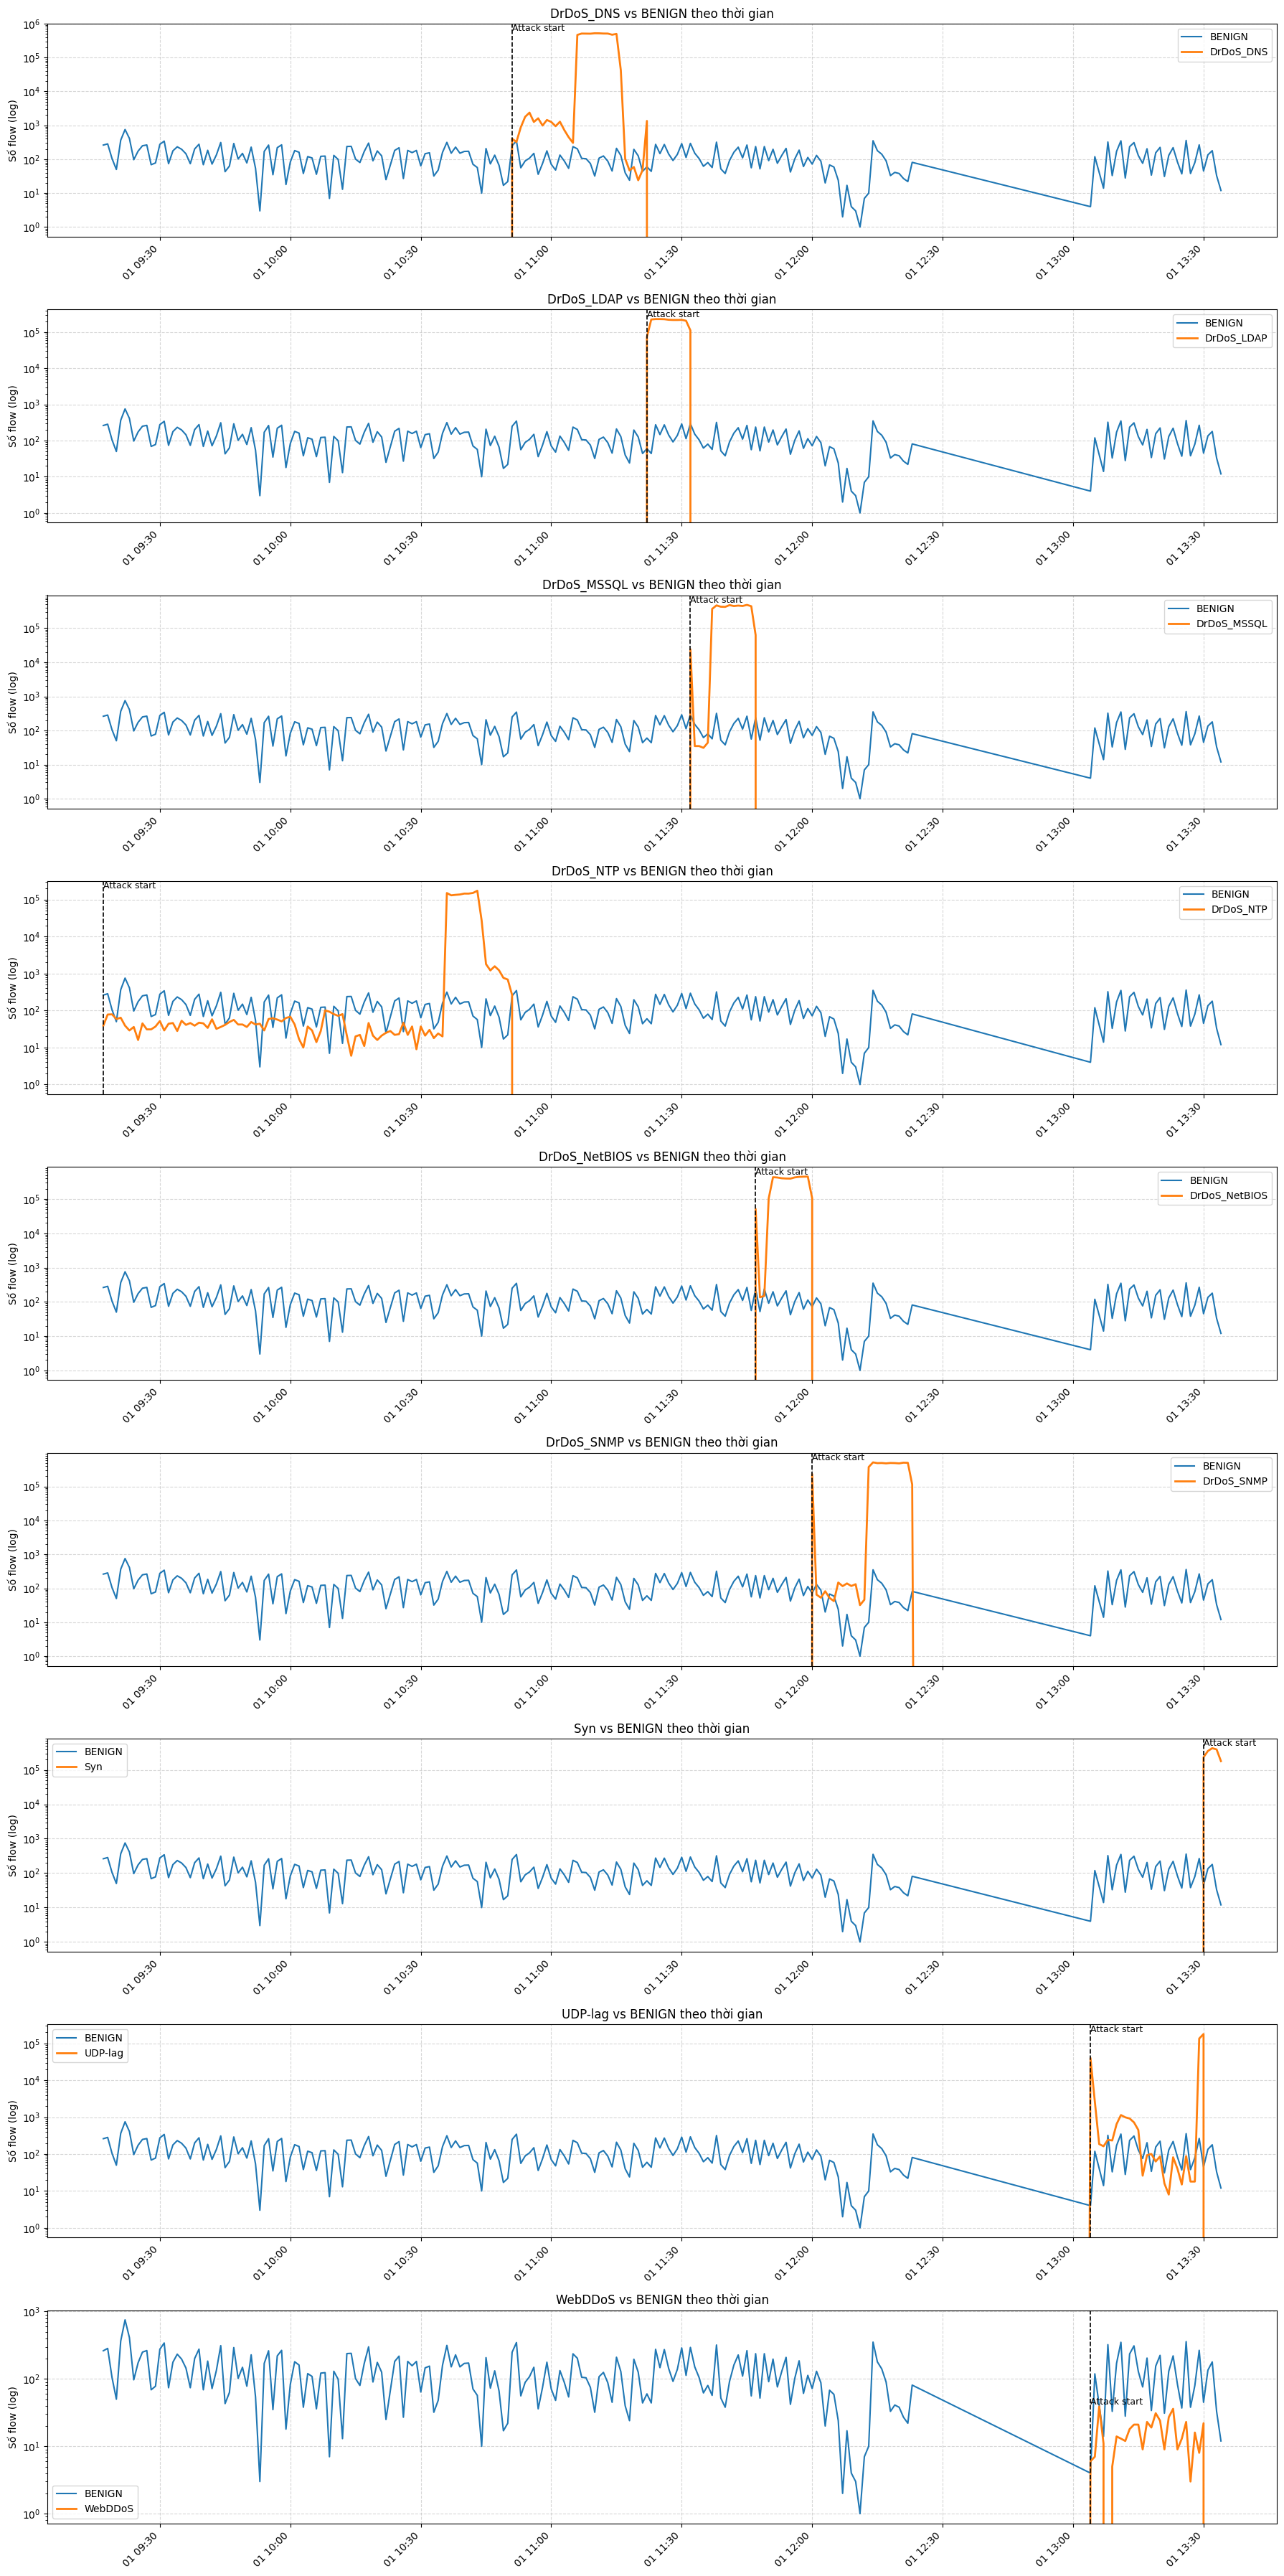

In [57]:
import matplotlib.pyplot as plt
import numpy as np

attack_cols = [c for c in pivot_counts.columns if c not in ["minute", "BENIGN"]]
times = pivot_counts["minute"]
benign = pivot_counts["BENIGN"].values

n = len(attack_cols)
plt.figure(figsize=(18, 4 * n))

for i, col in enumerate(attack_cols, start=1):
    plt.subplot(n, 1, i)

    y = pivot_counts[col].values

    # vẽ lưu lượng BENIGN
    plt.plot(times, benign, linewidth=1.5, label="BENIGN")

    # vẽ lưu lượng tấn công cho col hiện tại
    plt.plot(times, y, linewidth=2.0, label=str(col))

    # tìm thời điểm đầu tiên loại tấn công này xuất hiện
    nonzero_idx = np.nonzero(y)[0]
    if len(nonzero_idx) > 0:
        first_idx = nonzero_idx[0]
        first_time = times.iloc[first_idx]

        # vẽ đường thẳng đánh dấu thời điểm bắt đầu tấn công
        plt.axvline(first_time, linestyle="--", linewidth=1.2, color="black")
        plt.text(
            first_time,
            max(y) if max(y) > 0 else 1,
            "Attack start",
            ha="left",
            va="bottom",
            fontsize=9,
        )

    plt.yscale("log")
    plt.ylabel("Số flow (log)")
    plt.title(f"{col} vs BENIGN theo thời gian")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xticks(rotation=45, ha="right")
    plt.legend()

plt.tight_layout()
plt.show()


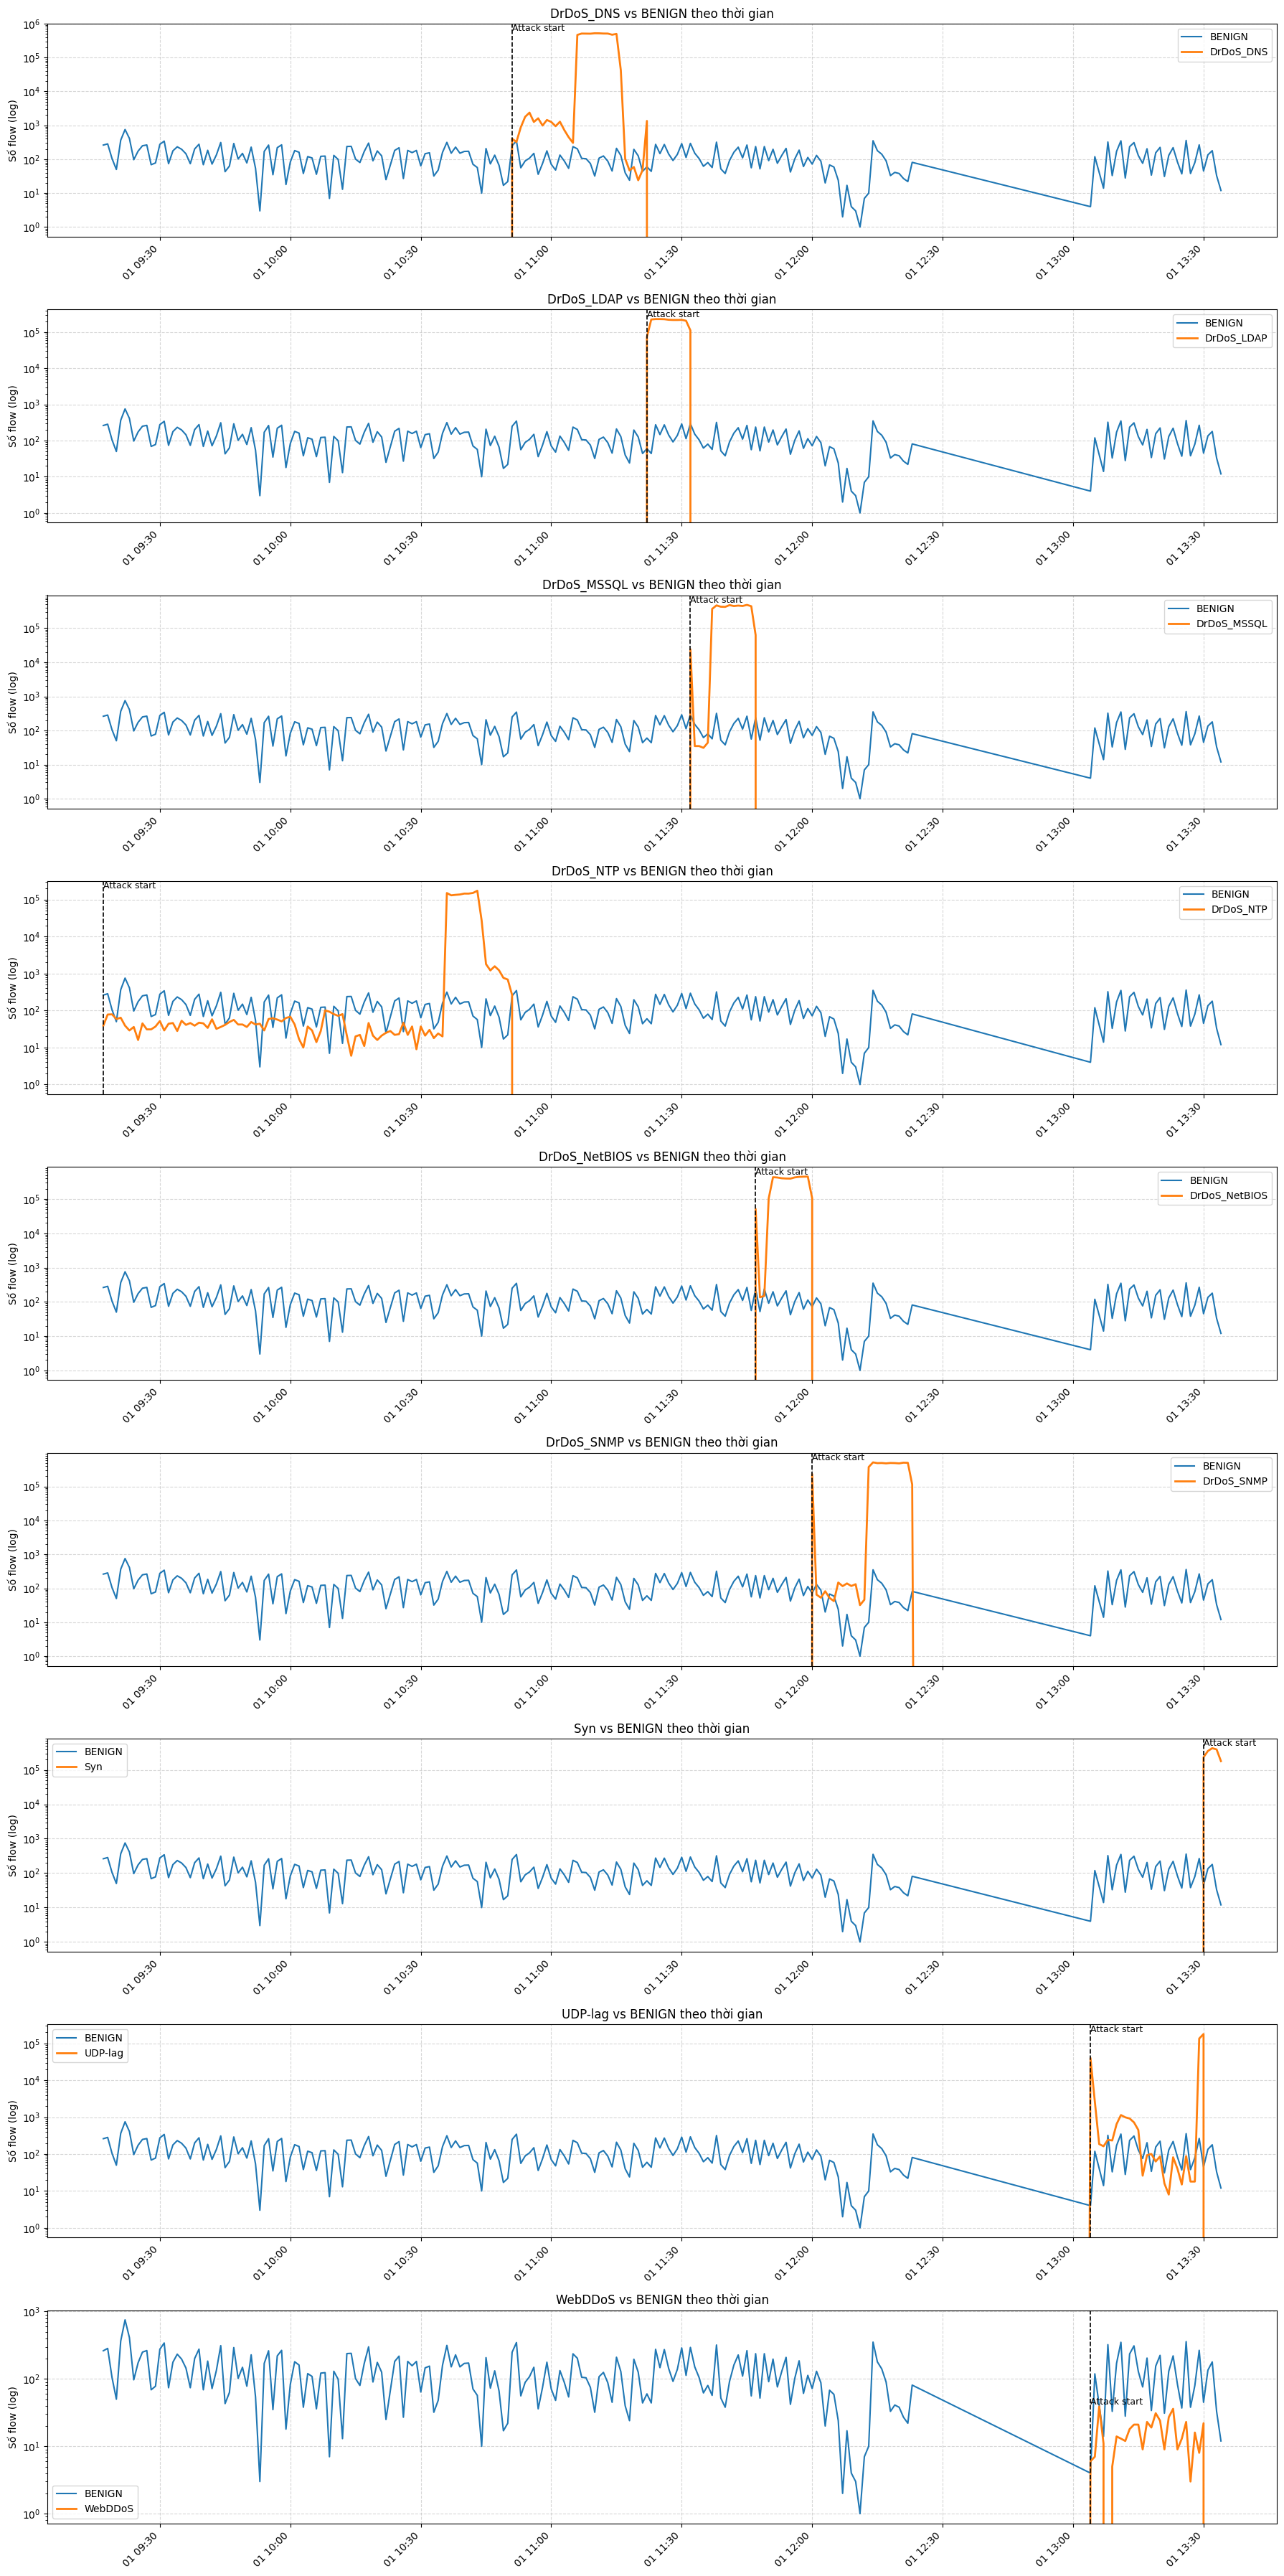

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# lấy danh sách các attack (loại bỏ minute và BENIGN)
attack_cols = [c for c in pivot_counts.columns if c not in ["minute", "BENIGN"]]

times = pivot_counts["minute"]
benign = pivot_counts["BENIGN"].values

n = len(attack_cols)
plt.figure(figsize=(18, 4 * n))

for i, col in enumerate(attack_cols, start=1):
    plt.subplot(n, 1, i)

    attack_y = pivot_counts[col].values

    # vẽ BENIGN
    plt.plot(times, benign, linewidth=1.5, label="BENIGN")

    # vẽ attack hiện tại
    plt.plot(times, attack_y, linewidth=2.0, label=col)

    # tìm thời điểm attack xuất hiện lần đầu
    nonzero_idx = np.nonzero(attack_y)[0]
    if len(nonzero_idx) > 0:
        first_idx = nonzero_idx[0]
        first_time = times.iloc[first_idx]

        # vẽ đường đánh dấu thời điểm tấn công bắt đầu
        plt.axvline(first_time, linestyle="--", linewidth=1.2, color="black")
        plt.text(
            first_time,
            max(attack_y) if max(attack_y) > 0 else 1,
            "Attack start",
            ha="left",
            va="bottom",
            fontsize=9,
        )

    plt.yscale("log")
    plt.ylabel("Số flow (log)")
    plt.title(f"{col} vs BENIGN theo thời gian")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xticks(rotation=45, ha="right")
    plt.legend()

plt.tight_layout()
plt.show()


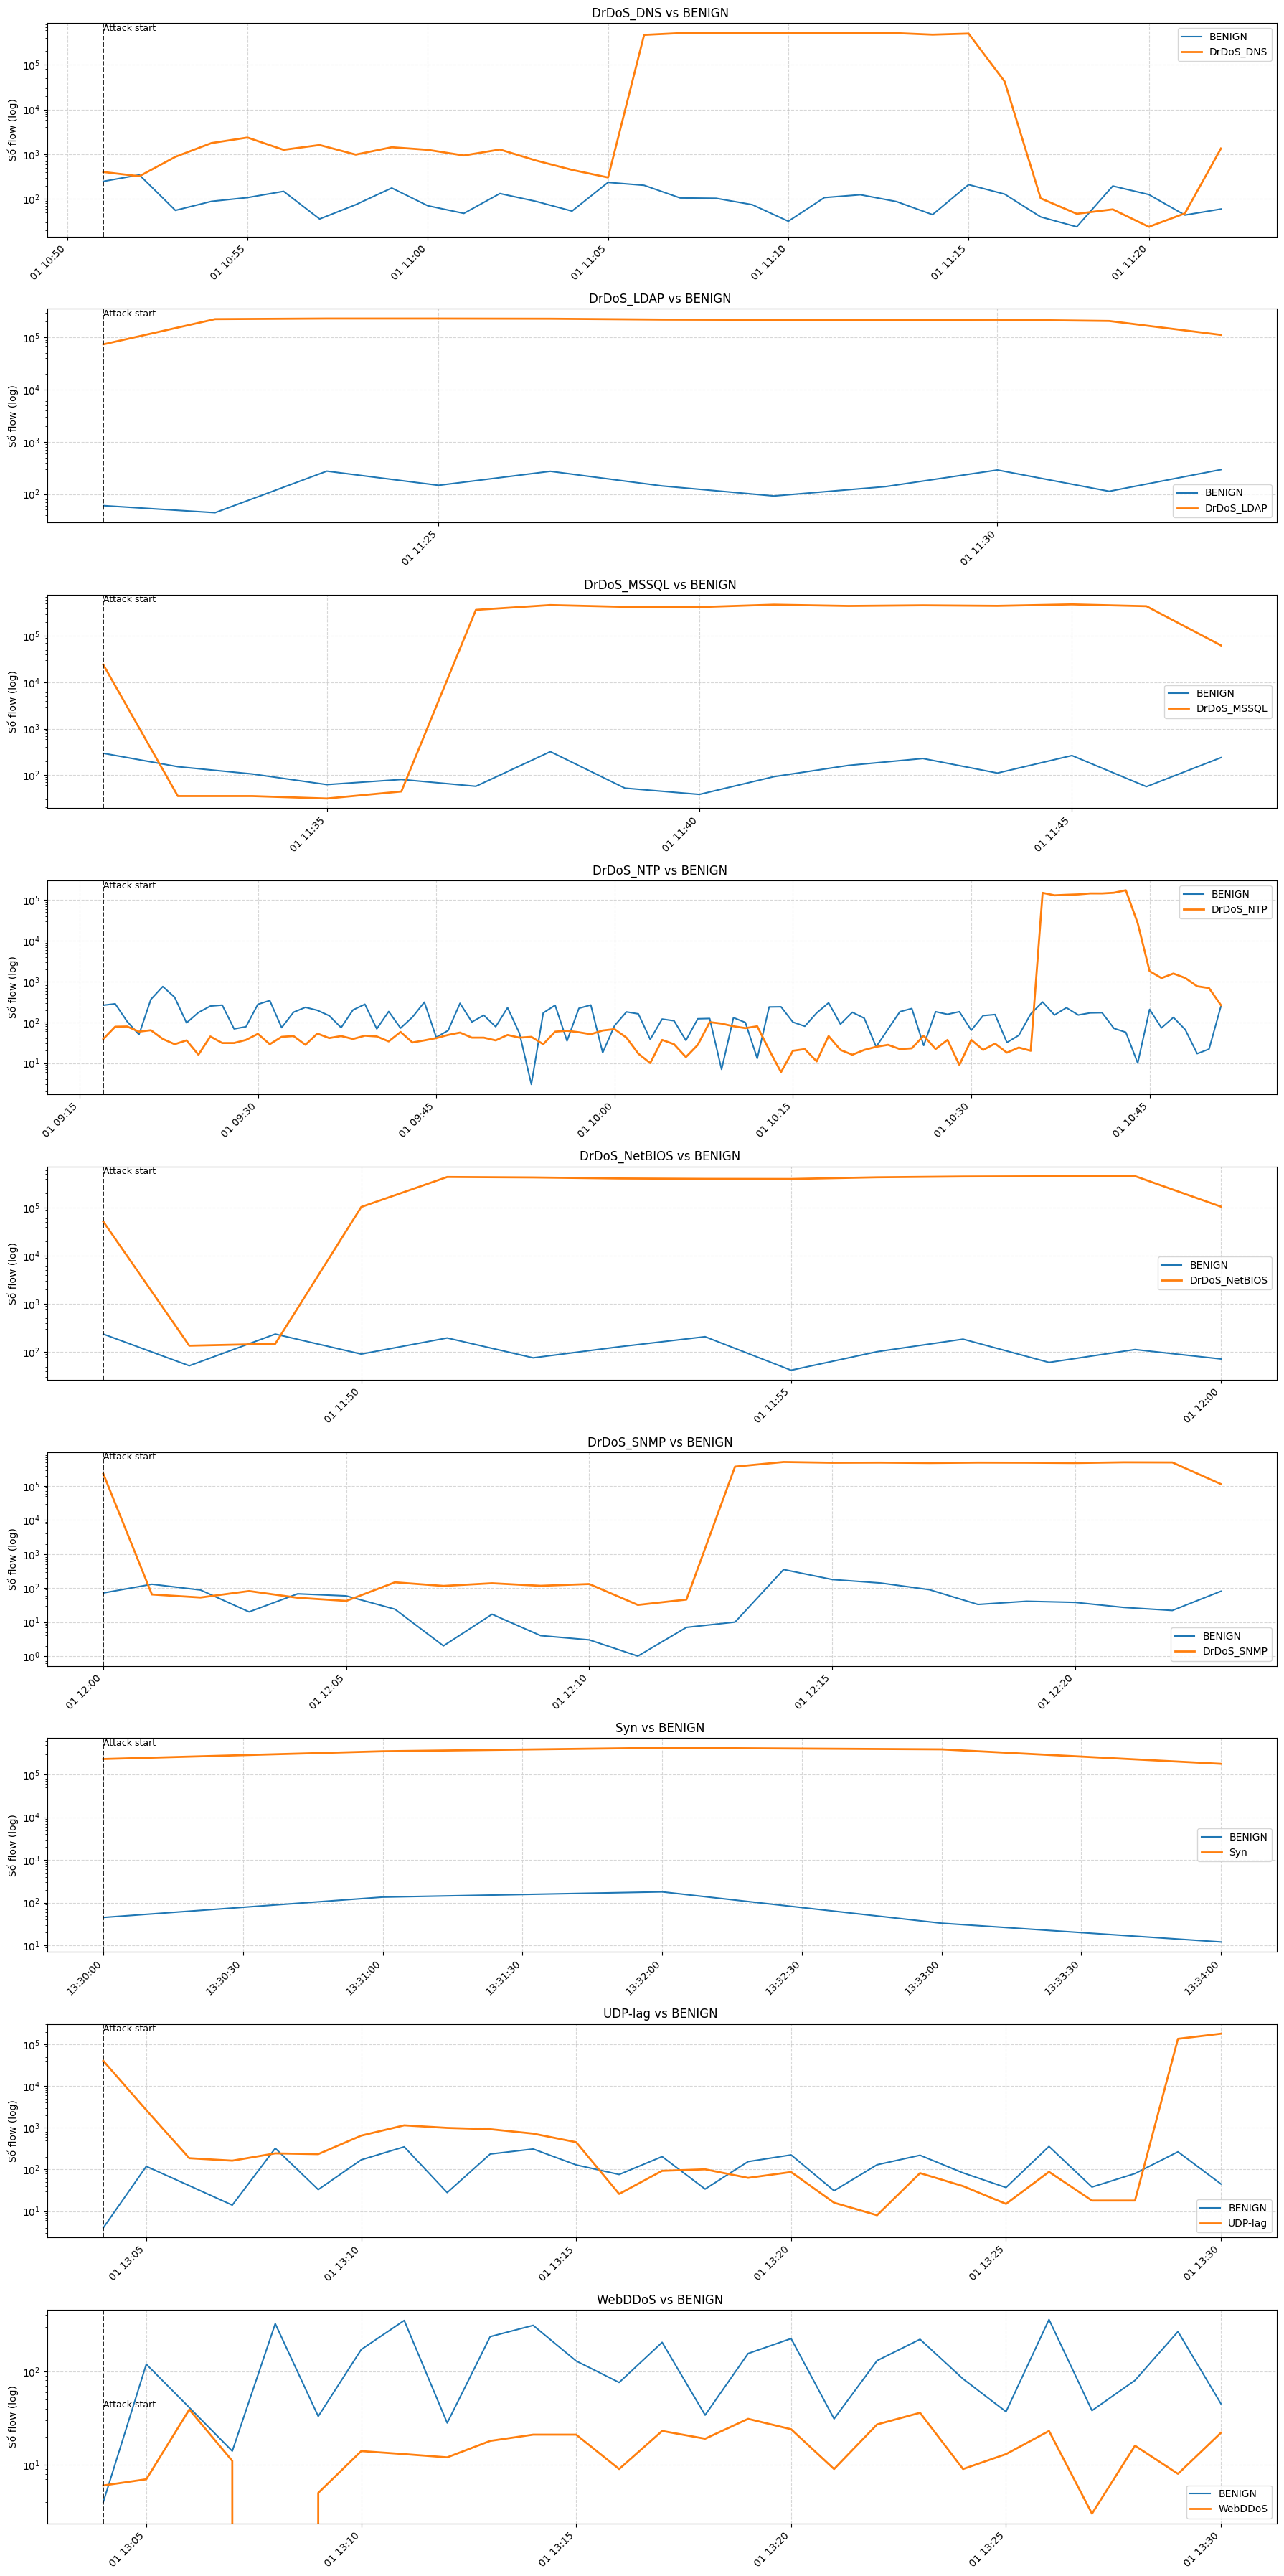

In [60]:
import matplotlib.pyplot as plt
import numpy as np

# danh sách attack (loại bỏ minute và BENIGN)
attack_cols = [c for c in pivot_counts.columns if c not in ["minute", "BENIGN"]]

times_full = pivot_counts["minute"]
benign_full = pivot_counts["BENIGN"].values

n = len(attack_cols)
plt.figure(figsize=(18, 4 * n))

for i, col in enumerate(attack_cols, start=1):
    plt.subplot(n, 1, i)

    attack_y_full = pivot_counts[col].values

    # tìm khoảng thời gian loại tấn công xuất hiện
    idx = np.nonzero(attack_y_full)[0]

    if len(idx) == 0:
        continue

    start_idx = idx[0]
    end_idx = idx[-1]

    # cắt timeline theo khoảng attack xuất hiện
    times = times_full.iloc[start_idx:end_idx + 1]
    attack_y = attack_y_full[start_idx:end_idx + 1]
    benign_y = benign_full[start_idx:end_idx + 1]

    # vẽ BENIGN trong khoảng này
    plt.plot(times, benign_y, linewidth=1.5, label="BENIGN")

    # vẽ attack trong khoảng này
    plt.plot(times, attack_y, linewidth=2.0, label=col)

    # đánh dấu thời điểm bắt đầu
    first_time = times.iloc[0]
    plt.axvline(first_time, linestyle="--", linewidth=1.2, color="black")
    plt.text(
        first_time,
        max(attack_y) if max(attack_y) > 0 else 1,
        "Attack start",
        ha="left",
        va="bottom",
        fontsize=9,
    )

    plt.yscale("log")
    plt.ylabel("Số flow (log)")
    plt.title(f"{col} vs BENIGN ")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xticks(rotation=45, ha="right")
    plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
spark.stop()